In [4]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import math

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


data: x(8000, 2)  m=4  prior std~0.50 rad  alias spacing 2pi/m=1.57 rad
H(y|x)   = 3.571 nats   (fine, but 4-fold aliased)
H(y|z)   = 5.550 nats   (coarse, unaliased)
H(y|x,z) = 2.559 nats  (resolved)
  unique from z (resolves alias): 1.012  ~ log m = 1.386
  unique from x (localizes y):    2.991


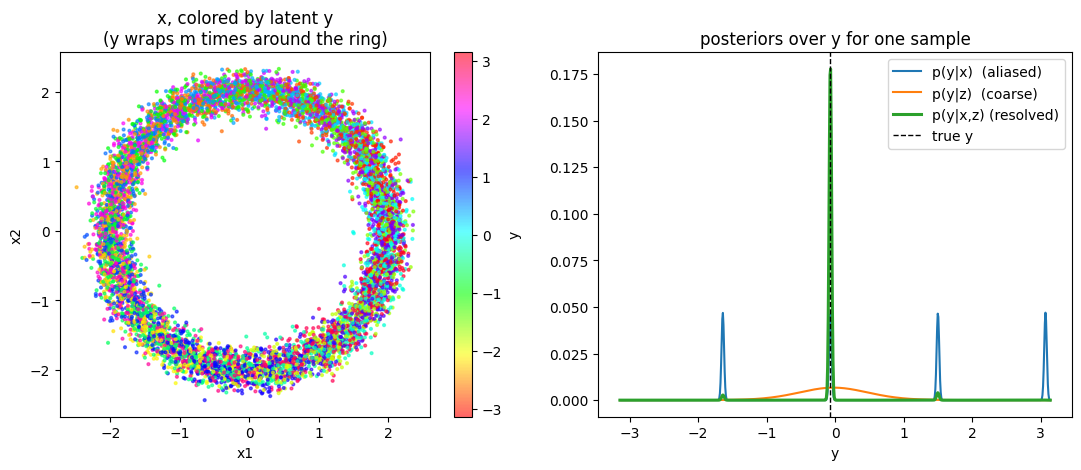

In [5]:
from a_datasets.ring.data import WrappedPhaseRing, grid_entropy

ds = WrappedPhaseRing(n=8_000, m=4, kappa=4.0, sigma=0.15, r0=2.0,
                        seed=0, return_latents=True)
x, y, z = ds.x, ds.y, ds.z
print(f"data: x{tuple(x.shape)}  m={ds.m}  prior std~{ds.kappa**-0.5:.2f} rad  "
        f"alias spacing 2pi/m={2*math.pi/ds.m:.2f} rad")

_, p_x  = ds.posterior_y_given_x(x)
_, p_z  = ds.posterior_y_given_z(z)
_, p_xz = ds.posterior_y_given_xz(x, z)
H = lambda p: grid_entropy(p).mean().item()
print(f"H(y|x)   = {H(p_x):.3f} nats   (fine, but {ds.m}-fold aliased)")
print(f"H(y|z)   = {H(p_z):.3f} nats   (coarse, unaliased)")
print(f"H(y|x,z) = {H(p_xz):.3f} nats  (resolved)")
print(f"  unique from z (resolves alias): {H(p_x)-H(p_xz):.3f}  ~ log m = {math.log(ds.m):.3f}")
print(f"  unique from x (localizes y):    {H(p_z)-H(p_xz):.3f}")

# ----- optional figure -------------------------------------------------- #
import matplotlib.pyplot as plt

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.6))

sc = ax0.scatter(x[:, 0], x[:, 1], c=y, cmap="hsv", s=4, alpha=0.6)
ax0.set_aspect("equal"); ax0.set_title("x, colored by latent y\n(y wraps m times around the ring)")
ax0.set_xlabel("x1"); ax0.set_ylabel("x2")
fig.colorbar(sc, ax=ax0, label="y")

i = 0
yg, _ = ds.posterior_y_given_x(x[i:i+1])
_, px  = ds.posterior_y_given_x(x[i:i+1])
_, pz  = ds.posterior_y_given_z(z[i:i+1])
_, pxz = ds.posterior_y_given_xz(x[i:i+1], z[i:i+1])
ax1.plot(yg, px[0],  label="p(y|x)  (aliased)")
ax1.plot(yg, pz[0],  label="p(y|z)  (coarse)")
ax1.plot(yg, pxz[0], label="p(y|x,z) (resolved)", lw=2.2)
ax1.axvline(float(y[i]), color="k", ls="--", lw=1, label="true y")
ax1.set_title("posteriors over y for one sample"); ax1.set_xlabel("y"); ax1.legend()

fig.tight_layout()
# fig.savefig("wrapped_phase_ring.png", dpi=130)
# print("saved figure -> wrapped_phase_ring.png")

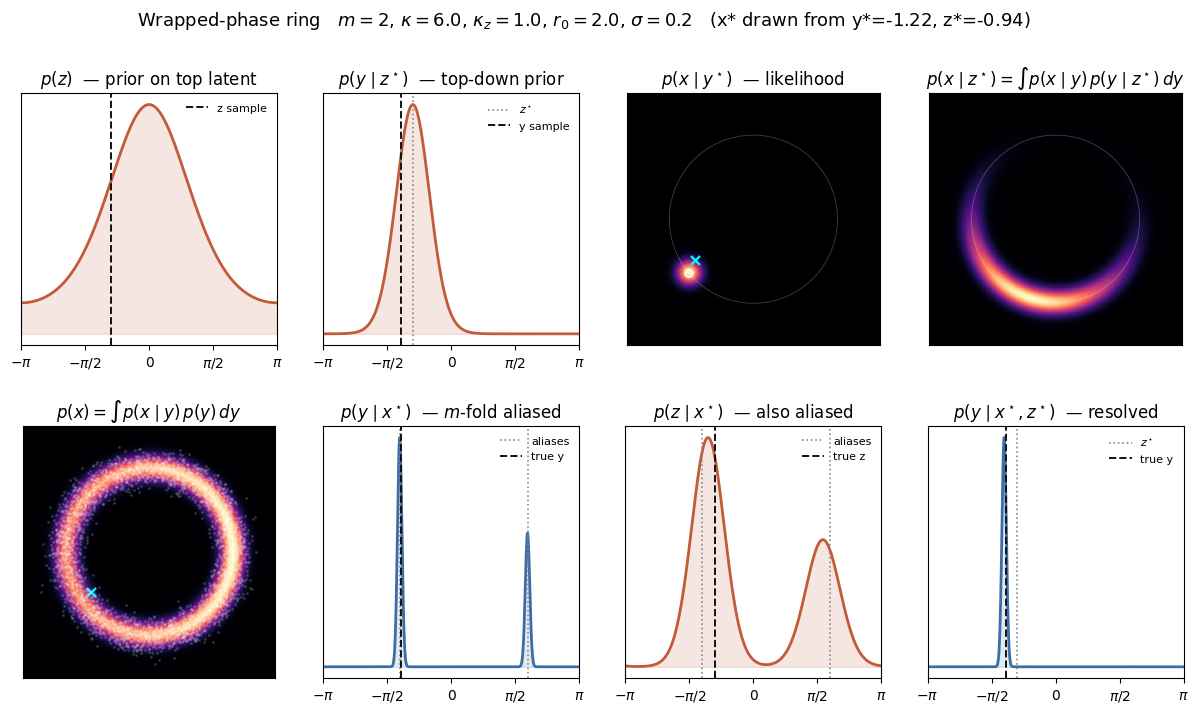

In [9]:
from a_datasets.ring.data import plot_distributions

plot_distributions(seed=5, m=2, kappa=6., kappa_z=1.0, r0=2.0, sigma=0.2)

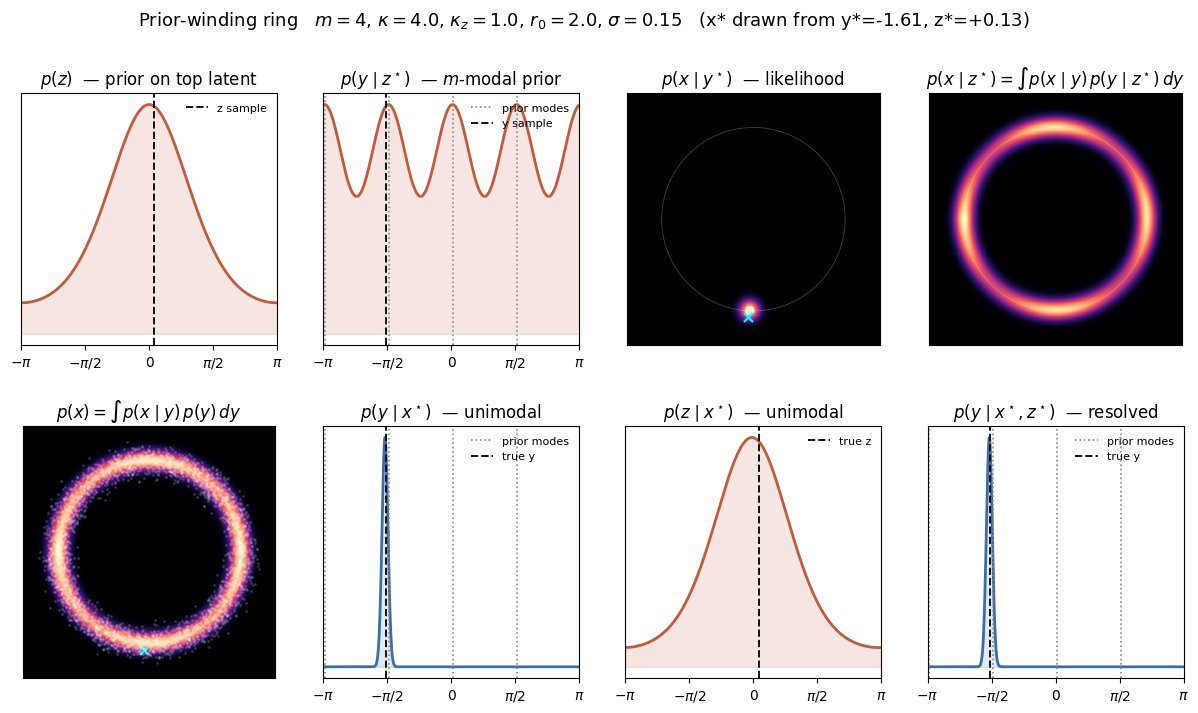

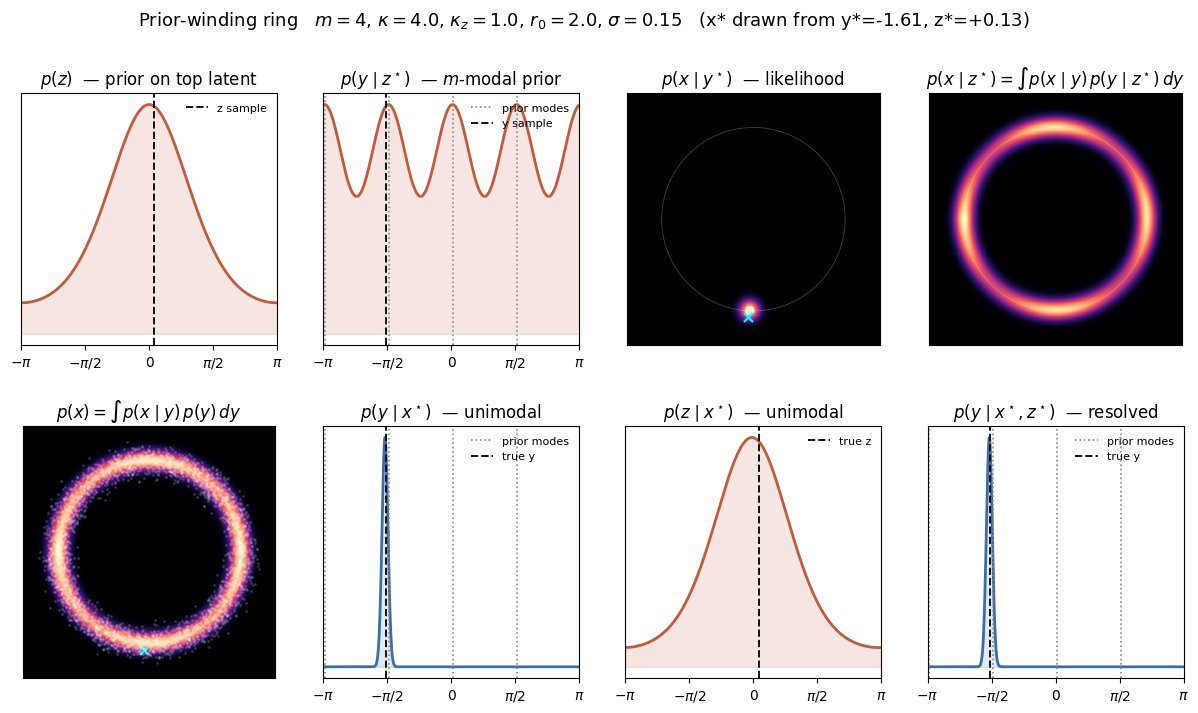

In [12]:
from a_datasets.ring.data_multimodal import plot_distributions
plot_distributions()

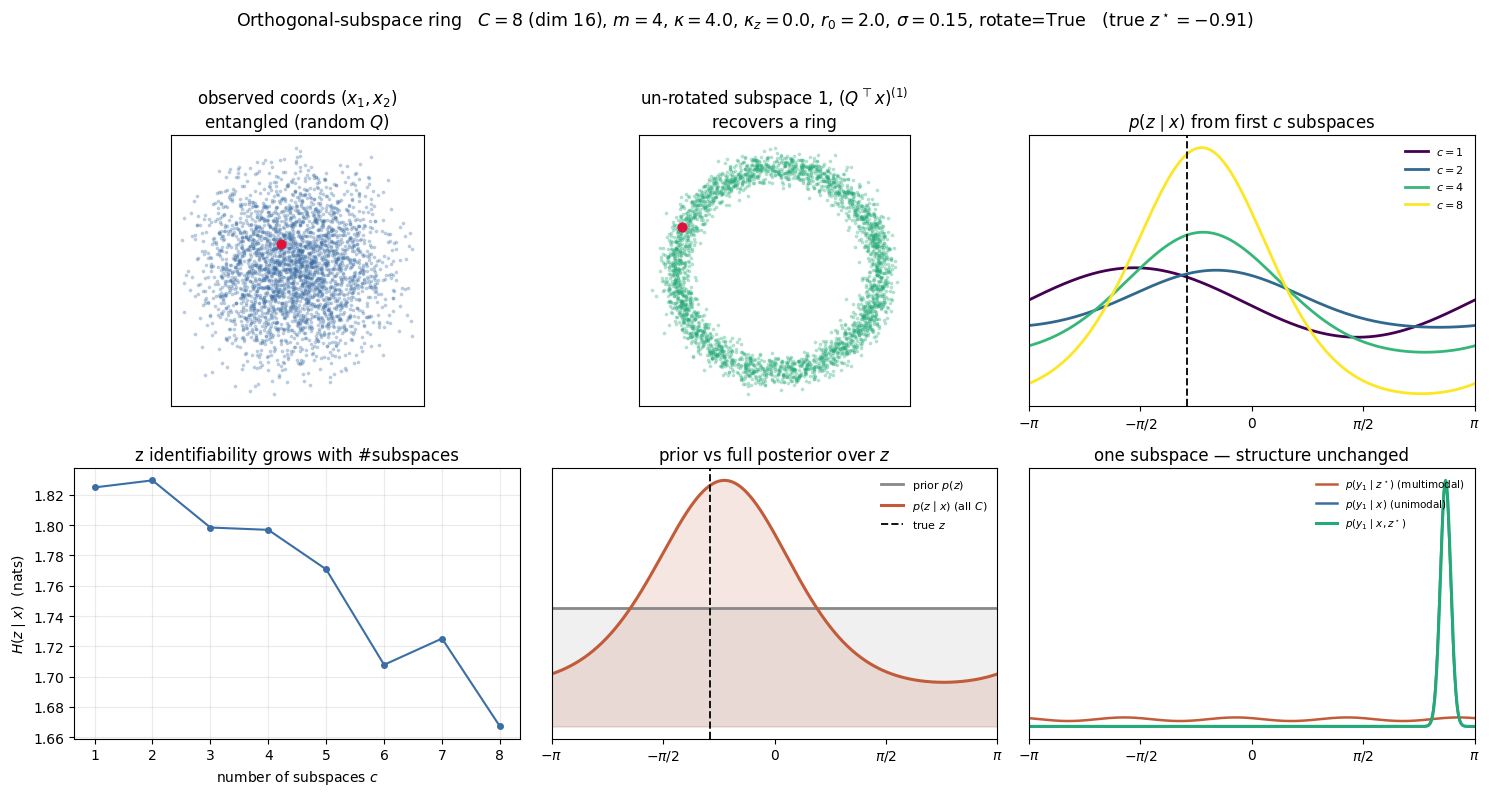

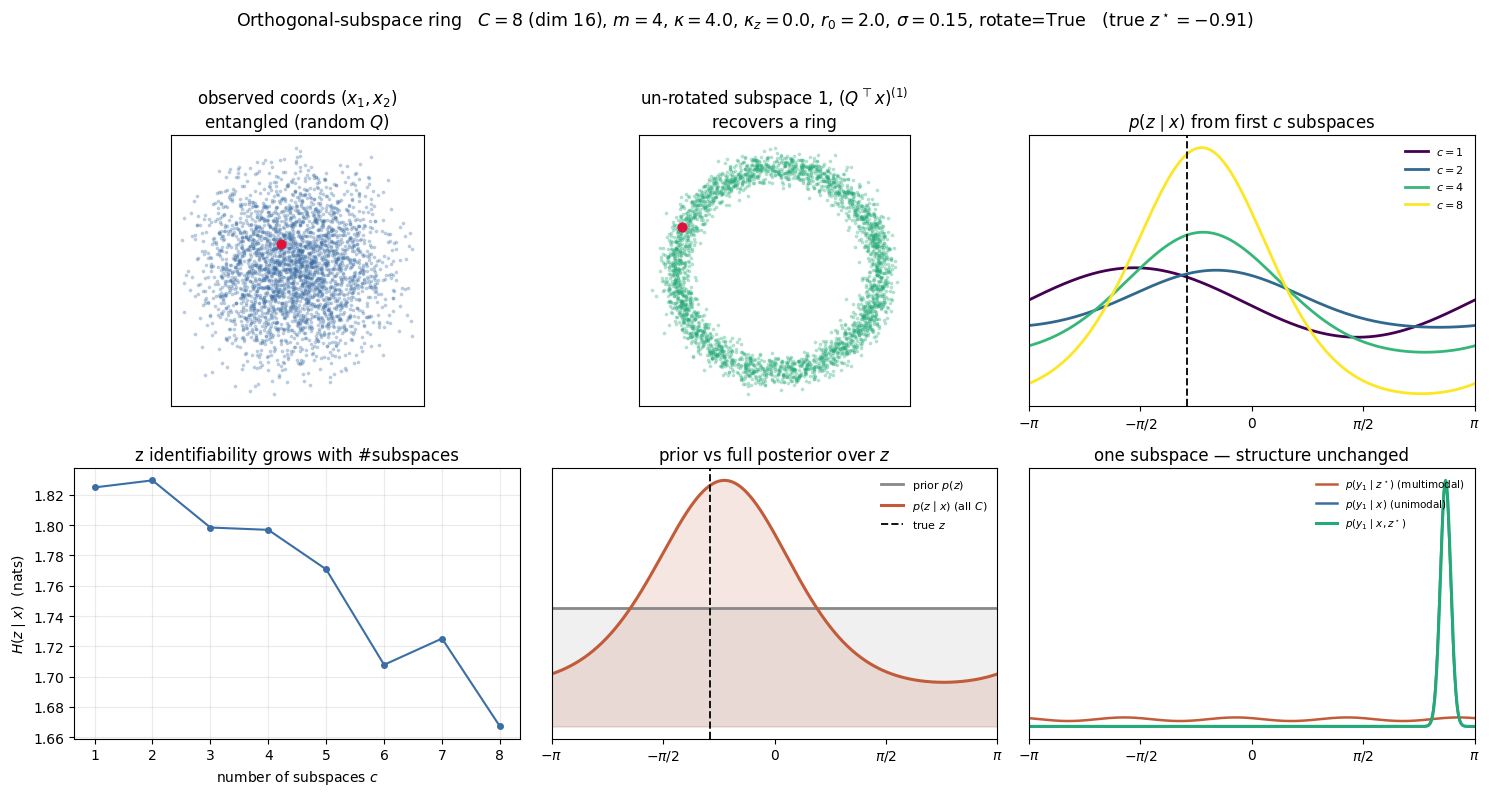

In [13]:
from a_datasets.ring.data_orthogonal import plot_distributions
plot_distributions()

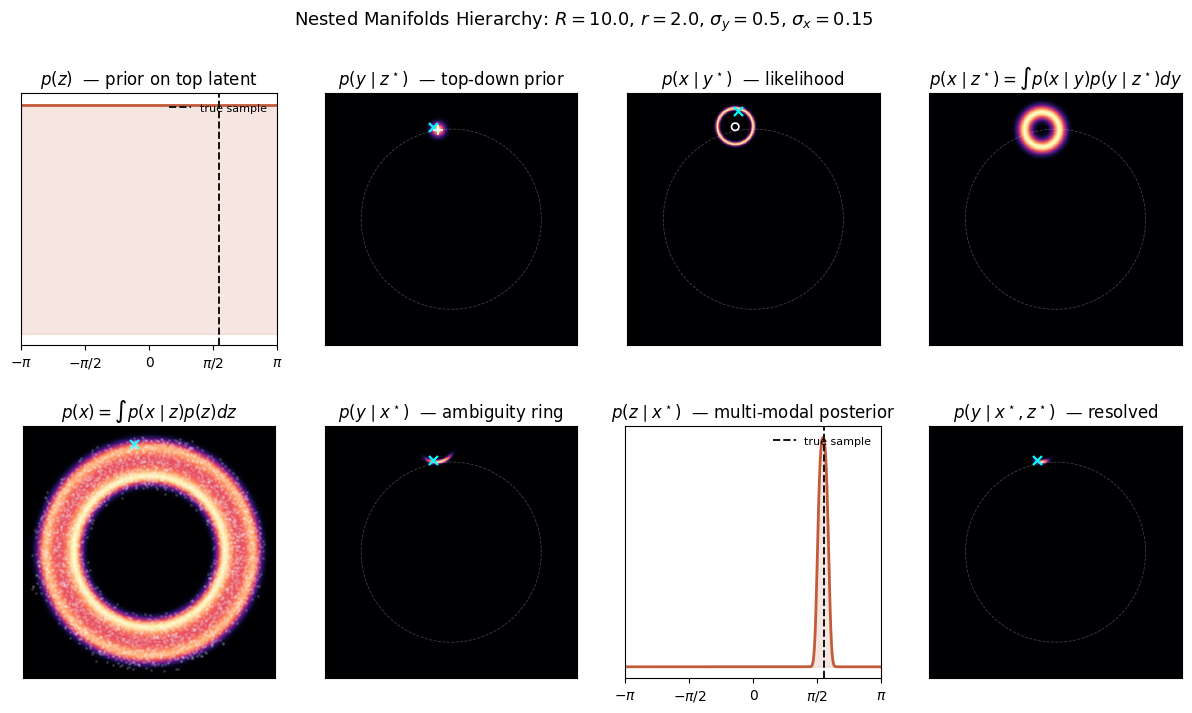

In [14]:
from a_datasets.circles_of_circles.data import plot_distributions
plot_distributions()